# 01 — Checking the pretrained flow maps

Two pretrained checkpoints ship with the VFM code, in `../checkerboard_example/checkpoints/`.
`fm_model.pt` predicts instantaneous velocity and needs many Euler steps. `mf_model.pt` predicts
average velocity over an interval and generates in one step. Both are a SiLU MLP,
`MeanFlowMLP(hidden=512, depth=6)`.

Time runs from t=1 at noise to t=0 at data, so sampling integrates downwards.

The conditional experiments in the later notebooks all use `mf_model.pt`.

## Setup

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# the authors' code sets no seeds
torch.manual_seed(0)
np.random.seed(0)

CKPT_DIR = Path("../checkerboard_example/checkpoints")
FIG_DIR = Path("figures/01"); FIG_DIR.mkdir(parents=True, exist_ok=True)


device: cuda


## Checkerboard data

Rejection sampling, copied from `train_vfm.py`. Draw uniform points in $[0,1]^2$, keep those
whose 4x4 grid cell $(i,j)$ has $i+j$ even, then rescale to $[-2,2]^2$.

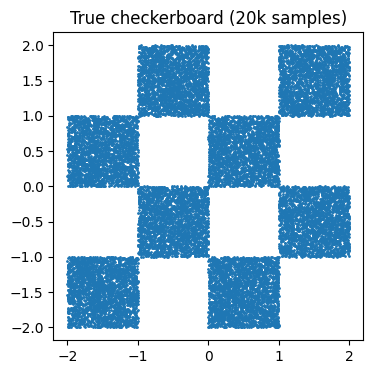

In [2]:
def sample_checkerboard(n_samples, n_squares=4):
    assert n_squares % 2 == 0

    # sample candidate points
    x = np.random.rand(n_samples, 2)

    # map to square indices
    idx = (x * n_squares).astype(int)

    # checkerboard mask
    mask = (idx[:, 0] + idx[:, 1]) % 2 == 0

    # resample rejected points
    while not mask.all():
        n_bad = (~mask).sum()
        x_new = np.random.rand(n_bad, 2)
        idx_new = (x_new * n_squares).astype(int)

        x[~mask] = x_new
        idx[~mask] = idx_new
        mask = (idx[:, 0] + idx[:, 1]) % 2 == 0

    return 4.0 * (x - np.array([[0.5, 0.5]]))


x_real = sample_checkerboard(20_000)
plt.figure(figsize=(4, 4))
plt.scatter(x_real[:, 0], x_real[:, 1], s=1)
plt.axis("equal"); plt.title("True checkerboard (20k samples)")
plt.savefig(FIG_DIR / "true_data.png", dpi=120, bbox_inches="tight")
plt.show()


## Model and samplers

`MeanFlowMLP` is copied from `train_vfm.py`. Its forward pass concatenates `[z, t, r]`, with t
before r, opposite to the argument order. The checkpoints were trained this way, so it must not
be changed.

`f_theta` is the K-step flow map sampler. It applies
$z \leftarrow z - (t_i - t_{i-1})\, u_\theta(z, t_{i-1}, t_i)$ from t=1 down to t=0, querying
the average velocity over each interval. This is the sampler for `mf_model`.

`euler_tt` is plain Euler integration, querying the instantaneous velocity $u_\theta(z,t,t)$.
This is the sampler for `fm_model`, which was trained only at r=t.

In [3]:
class MeanFlowMLP(nn.Module):
    """
    u_theta(z, r, t) -> R^2
    Inputs: z in R^2, (t, r) scalars (two extra channels)
    """
    def __init__(self, hidden=256, depth=4):
        super().__init__()
        layers = []
        in_dim = 2 + 2  # z + (t, r)
        dim = in_dim
        for _ in range(depth):
            layers += [nn.Linear(dim, hidden), nn.SiLU()]
            dim = hidden
        layers += [nn.Linear(dim, 2)]
        self.net = nn.Sequential(*layers)

    def forward(self, z, r, t):
        inp = torch.cat([z, t, r], dim=1)
        return self.net(inp)


@torch.no_grad()
def f_theta(z, u_model, K=1):
    # Flow-map sampler: queries average velocity u(z, r, t) over each interval.
    # z: (B, 2). Integrate from t=1 (noise) down to t=0 (data) in K steps.
    ts = torch.linspace(0.0, 1.0, K + 1, device=z.device)
    for i in range(K, 0, -1):
        t_i = torch.full((z.shape[0], 1), ts[i].item(), device=z.device)
        r_i = torch.full((z.shape[0], 1), ts[i - 1].item(), device=z.device)
        z = z - (t_i - r_i) * u_model(z, r_i, t_i)
    return z


@torch.no_grad()
def euler_tt(z, u_model, K):
    # Euler sampler (Colab's `em_sampling`): queries instantaneous velocity
    # u(z, t, t) at the CURRENT time t, stepping t: 1 -> 0.
    ts = torch.linspace(1.0, 0.0, K + 1, device=z.device)
    dt = ts[1] - ts[0]  # negative: we integrate downwards
    for i in range(K):
        t_now = ts[i] * torch.ones(z.shape[0], 1, device=z.device)
        z = z + u_model(z, t_now, t_now) * dt
    return z


## Load the two checkpoints

Each file is a bare `state_dict`, so loading without error already confirms the architecture.

In [4]:
def load_model(path):
    model = MeanFlowMLP(hidden=512, depth=6).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model

fm_model = load_model(CKPT_DIR / "fm_model.pt")
mf_model = load_model(CKPT_DIR / "mf_model.pt")

# Confirm the two files hold different weights
diff = max((pf - pm).abs().max().item()
           for pf, pm in zip(fm_model.parameters(), mf_model.parameters()))
print(f"max |fm - mf| over all parameters: {diff:.4f}  (>0 means different weights)")


max |fm - mf| over all parameters: 0.4135  (>0 means different weights)


## Sample from each checkpoint

`fm_model` with `euler_tt` at K=1 and K=100. `mf_model` with `f_theta` at K=1, 2, 5, 10, 20, 50.
The same noise batch is used everywhere, so differences between panels come from the model and
the step count rather than from sampling.

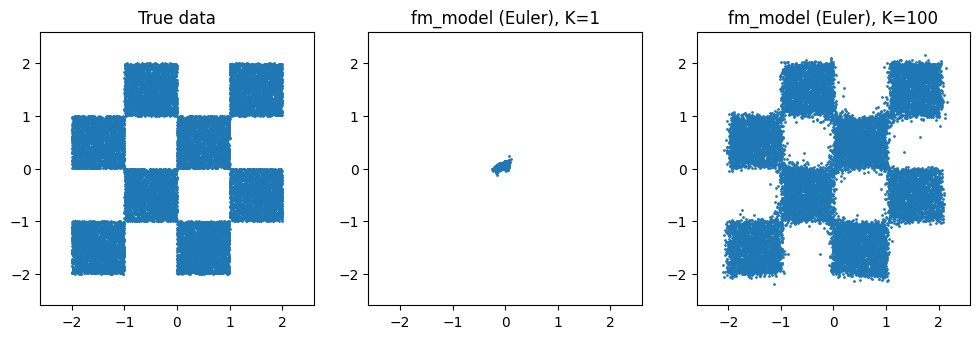

In [5]:
N = 20_000
z_noise = torch.randn(N, 2, device=device)  # same noise for every run

# fm_model: Euler sampler (instantaneous velocity)
fm_samples = {K: euler_tt(z_noise.clone(), fm_model, K=K).cpu().numpy()
              for K in (1, 100)}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].scatter(x_real[:, 0], x_real[:, 1], s=1)
axes[0].set_title("True data")
for ax, (K, x_gen) in zip(axes[1:], fm_samples.items()):
    ax.scatter(x_gen[:, 0], x_gen[:, 1], s=1)
    ax.set_title(f"fm_model (Euler), K={K}")
for ax in axes:
    ax.set_xlim(-2.6, 2.6); ax.set_ylim(-2.6, 2.6); ax.set_aspect("equal")
plt.savefig(FIG_DIR / "fm_samples.png", dpi=120, bbox_inches="tight")
plt.show()


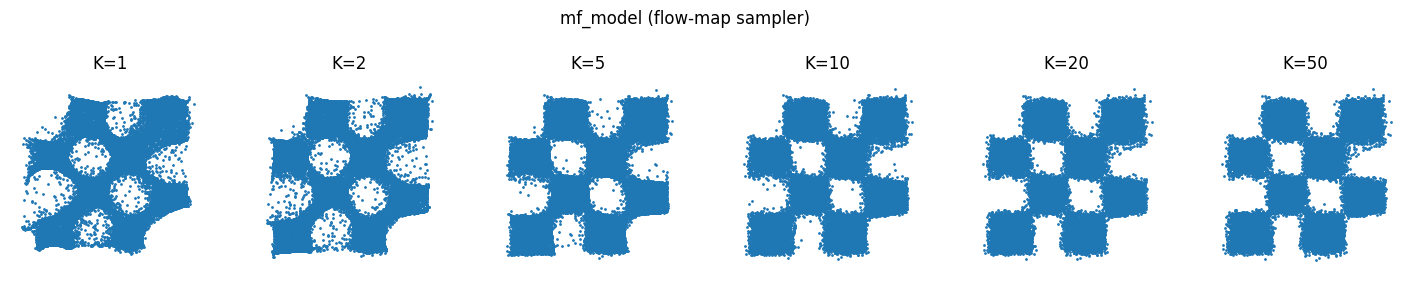

In [6]:
# mf_model: flow-map sampler, authors' K sweep
Ks = [1, 2, 5, 10, 20, 50]
mf_samples = {K: f_theta(z_noise.clone(), mf_model, K=K).cpu().numpy()
              for K in Ks}

fig, axes = plt.subplots(1, len(Ks), figsize=(3 * len(Ks), 3))
for ax, K in zip(axes, Ks):
    x_gen = mf_samples[K]
    ax.scatter(x_gen[:, 0], x_gen[:, 1], s=1)
    ax.set_title(f"K={K}")
    ax.set_xlim(-2.6, 2.6); ax.set_ylim(-2.6, 2.6)
    ax.set_aspect("equal"); ax.axis("off")
fig.suptitle("mf_model (flow-map sampler)", y=1.05)
plt.savefig(FIG_DIR / "mf_samples_K_sweep.png", dpi=120, bbox_inches="tight")
plt.show()


## Support accuracy

The fraction of samples landing inside a filled checkerboard cell. Invert the data transform,
find each point's grid cell, and test that $i+j$ is even. True data scores 1.0.

The authors' `MetricPlots.ipynb` implies a prior SACC for `mf_model` of 0.868 at K=1 and 0.894
at K=4.

In [7]:
def support_accuracy(x):
    u = x / 4.0 + 0.5                       # invert the rescaling, back to [0,1]^2
    inside = ((u >= 0) & (u < 1)).all(axis=1)
    idx = np.floor(u * 4).astype(int).clip(0, 3)
    on_board = (idx[:, 0] + idx[:, 1]) % 2 == 0
    return (inside & on_board).mean()

print(f"{'true data':22s} SACC = {support_accuracy(x_real):.4f}")
for K, x_gen in fm_samples.items():
    print(f"fm_model (Euler) K={K:<4d} SACC = {support_accuracy(x_gen):.4f}")
for K, x_gen in mf_samples.items():
    print(f"mf_model K={K:<11d} SACC = {support_accuracy(x_gen):.4f}")


true data              SACC = 1.0000
fm_model (Euler) K=1    SACC = 0.6672
fm_model (Euler) K=100  SACC = 0.9392
mf_model K=1           SACC = 0.8717
mf_model K=2           SACC = 0.8943
mf_model K=5           SACC = 0.8882
mf_model K=10          SACC = 0.8980
mf_model K=20          SACC = 0.9064
mf_model K=50          SACC = 0.9122
